In [69]:
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from modelFuncs import *

In [70]:
#Use yfinance to download stock data for Novo Nordisk (NVO) from 2000 to 2025
nvo_obs = dataExtracterMonths('NVO', '2000-01-01', '2025-12-31')
nvo_obs

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 312 months


,Date,Open,High,Low,Close
0,2000-01-31,0.853510,0.940441,0.782384,0.783174
1,2000-02-29,0.796609,0.926216,0.787126,0.800561
2,2000-03-31,0.802141,0.930629,0.796609,0.874855
3,2000-04-30,0.860513,0.956126,0.815894,0.866888
4,2000-05-31,0.876449,1.097951,0.876449,1.047755
...,...,...,...,...,...
307,2025-08-31,47.732133,58.340000,44.548012,56.459999
308,2025-09-30,56.720001,62.320000,52.720001,55.490002
309,2025-10-31,56.009998,60.900002,48.490002,49.459999
310,2025-11-30,49.410000,50.430000,43.080002,49.349998


In [83]:
aapl_obs = dataExtracterDays('AAPL', '2024-01-01', '2025-12-31').dropna()
aapl_obs

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 729 days


,Date,Open,High,Low,Close
0,2024-01-02,185.225777,186.502522,181.999301,183.731308
1,2024-01-03,182.325916,183.968852,181.544030,182.355606
2,2024-01-04,180.277180,181.207518,179.020249,180.039658
3,2024-01-05,180.118838,180.880911,178.317544,179.317154
6,2024-01-08,180.217791,183.691712,179.633861,183.652115
...,...,...,...,...,...
721,2025-12-23,270.586809,272.245261,269.308007,272.105377
722,2025-12-24,272.085389,275.172497,271.945536,273.554016
724,2025-12-26,273.903708,275.112569,272.604905,273.144409
727,2025-12-29,272.435082,274.103504,272.095404,273.504089


In [95]:
aapl_data = aapl_obs[:260]
aapl_data

,Date,Open,High,Low,Close
0,2024-01-02,185.225777,186.502522,181.999301,183.731308
1,2024-01-03,182.325916,183.968852,181.544030,182.355606
2,2024-01-04,180.277180,181.207518,179.020249,180.039658
3,2024-01-05,180.118838,180.880911,178.317544,179.317154
6,2024-01-08,180.217791,183.691712,179.633861,183.652115
...,...,...,...,...,...
371,2025-01-07,241.659864,244.215908,240.038730,240.894058
372,2025-01-08,240.605648,242.385931,238.745812,241.381409
374,2025-01-10,238.706007,238.855201,231.734098,235.563187
377,2025-01-13,232.261212,233.395017,228.471914,233.126480


In [96]:
obs = aapl_obs[aapl_obs.columns[1:5]]
print("All observations: \n", obs)

data = aapl_data[aapl_data.columns[1:5]]
print("Data from start to cut: \n", data)


All observations: 
            Open        High         Low       Close
0    185.225777  186.502522  181.999301  183.731308
1    182.325916  183.968852  181.544030  182.355606
2    180.277180  181.207518  179.020249  180.039658
3    180.118838  180.880911  178.317544  179.317154
6    180.217791  183.691712  179.633861  183.652115
..          ...         ...         ...         ...
721  270.586809  272.245261  269.308007  272.105377
722  272.085389  275.172497  271.945536  273.554016
724  273.903708  275.112569  272.604905  273.144409
727  272.435082  274.103504  272.095404  273.504089
728  272.554970  273.823772  272.025467  272.824707

[501 rows x 4 columns]
Data from start to cut: 
            Open        High         Low       Close
0    185.225777  186.502522  181.999301  183.731308
1    182.325916  183.968852  181.544030  182.355606
2    180.277180  181.207518  179.020249  180.039658
3    180.118838  180.880911  178.317544  179.317154
6    180.217791  183.691712  179.633861  183.6

In [97]:
predict_size = len(obs)-len(data)
print("We are trying to predict the next ", predict_size, " units (e.g. days) of stock prices.")

We are trying to predict the next  241  units (e.g. days) of stock prices.


In [98]:
# Create the HMM. 
hmm_price = []
T = data.shape[0]

temp_T = T
first_time = True

window = 50

# Sliding window approach to predict future prices
while T < temp_T + predict_size:

    # Train HMM on data from T-D+1 to T
    train_data = obs.iloc[T-window:T]
    train_data = train_data.dropna()

    if(first_time):
      first_time = False
      model = hmm.GaussianHMM(n_components=5, random_state = 1)
    else:
      old_model= model
      model = hmm.GaussianHMM(n_components=5, init_params="c", random_state=1)
      model.startprob_ = old_model.startprob_
      model.transmat_ = old_model.transmat_
      model.means_ = old_model.means_

    model.fit(train_data)

    # Calculate original likelihood
    original_likelihood = model.score(train_data)

    # Loop to find new likelihood
    t=T
    min_diff = float('inf')
    min_t = T
    min_likelihood = original_likelihood
    while t-predict_size>  0:
        t = t-1

        train_data = obs.iloc[t-window:t]
        new_likelihood = model.score(train_data)
        if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

    # Calculate the predicted close price
    close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

    hmm_price.append(close_price)
    T=T+1

# Print the calculated prices
print("HMM Prices: ")
print(hmm_price)

# Plot the predicted and observed prices
close = []
truncated_obs = obs.iloc[T-predict_size:T]

for i in truncated_obs['Close']:
  close.append(i)

# plt.plot(hmm_price,marker='.', label = "HMM Predicted Price")
# plt.plot(close,marker = '.', label= "Observed Price")
# plt.ylabel("Close Price")
# plt.legend()
# plt.show()

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KeyError: 263

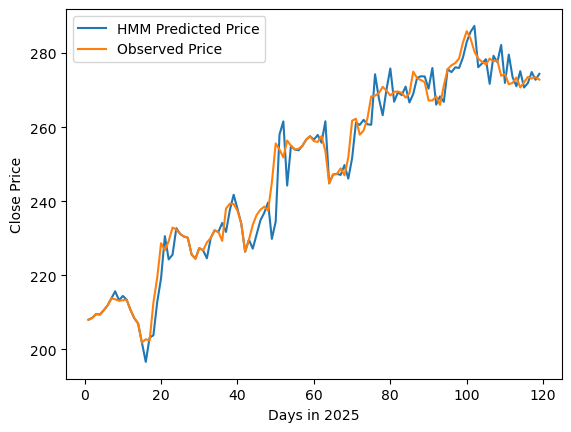

In [ ]:
amount_of_days = len(hmm_price)
days = np.arange(1, amount_of_days + 1)

fig, ax = plt.subplots((8,6))
ax.plot(days, hmm_price, label = "HMM Predicted Price")
ax.plot(days, close, label= "Observed Price")
ax.set_ylabel("Close Price")
ax.set_xlabel('Days in 2025')
ax.legend();

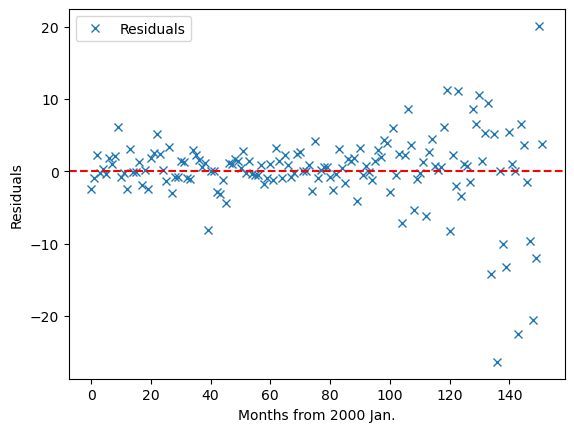

In [ ]:
#Calculate residuals: 

residuals = np.array(close) - np.array(hmm_price)
fig, ax = plt.subplots()
x_vals = np.arange(len(residuals))
ax.plot(x_vals, residuals,'x', label='Residuals')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Months from 2000 Jan.')
ax.set_ylabel('Residuals')
ax.legend();
